# 12 — CV plug-in ABCD expected limits

Cosmic-veto가 포함된 SR isolation plane에서 region A Data는 blind한 채,
\(N_A^{pred}=\kappa N_B^{Data}N_C^{Data}/N_D^{Data}\)를 1-bin background로 사용하는 expected-limit 중간 검증이다.

- \(\kappa=(N_A N_D)/(N_B N_C)\)는 SR background MC에서 계산한다.
- B/C/D Data Poisson uncertainty와 MC `sumw2` 기반 κ uncertainty를 plug-in background variance로 전파한다.
- signal은 SR A yield/variance를 사용한다.
- 이는 최종 simultaneous ABCD likelihood가 아니라 11번 MC-only baseline과의 비교 단계다.


In [1]:
from pathlib import Path
import os, re, shlex, subprocess, sys
import coffea.util
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import pandas as pd
import uproot
import yaml
from IPython.display import display

if int(np.__version__.split('.')[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault('numpy._core', _numpy_core)
    sys.modules.setdefault('numpy._core.numeric', _numpy_numeric)

BASE = Path.cwd().resolve()
if BASE.name != 'ABCD_Study':
    candidates = [BASE/'studies'/'ABCD_Study', BASE/'sidm'/'studies'/'ABCD_Study']
    BASE = next((p for p in candidates if p.is_dir()), candidates[-1])
REPOSITORY_PARENT = BASE.parents[2]
if str(REPOSITORY_PARENT) not in sys.path: sys.path.insert(0, str(REPOSITORY_PARENT))

BKG_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1'
DATA_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_data_full_merged_samples_v1'
SIGNAL_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1'
SIGNAL_YAMLS = [BASE.parents[1]/'configs/ntuples/signal_2mu2e_v10.yaml',
                BASE.parents[1]/'configs/ntuples/signal_4mu_v10.yaml']
MC_BASELINE = BASE/'combine_cv_mc_counting'/'expected_limits.csv'
OUT = BASE/'combine_cv_plugin_abcd'
SHAPES, CARDS, RESULTS, PLOTS = [OUT/x for x in ('shapes','datacards','results','plots')]
CMSSW = Path(os.environ.get('COMBINE_CMSSW_BASE', '/home/cms-jovyan/CMSSW_16_0_0'))
RUN_COMBINE = True
RUN_SCOPE = 'full'
LOW_STAT_NEFF = 10.0
RMAX_OVERRIDES = {}
for directory in (OUT, SHAPES, CARDS, RESULTS, PLOTS): directory.mkdir(parents=True, exist_ok=True)
print(BASE, BKG_DIR, DATA_DIR, SIGNAL_DIR, RUN_SCOPE, RUN_COMBINE, sep='\n')


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_data_full_merged_samples_v1
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1
full
True


## 1. SR histograms and A/B/C/D statistics

10·11번과 동일한 원래 binning 및 boundary를 사용한다. overflow는 fail 쪽 마지막 visible bin으로 접고 underflow는 제외한다.


In [2]:
CFG = {
    '2mu2e': {'hist':'mulj_egmlj_iso', 'channel':'test_SR_2mu2e_spread_cosAlpha_mu_veto', 'cuts':(0.25,0.10)},
    '4mu': {'hist':'mulj_mulj_iso', 'channel':'test_SR_4mu_spread_cosAlpha_mu_veto', 'cuts':(0.25,0.25)},
}
BKG_PREFIXES = ('QCD_', 'DYJetsTo', 'TTJets', 'WW', 'WZ', 'ZZ')

def load_hist(path, hist_name, channel):
    loaded = coffea.util.load(path)
    payload = loaded.get('out', loaded)[path.stem]
    h2d = payload['hists'][hist_name]
    return h2d[{'channel':channel}] if 'channel' in h2d.axes.name else h2d

def sum_hists(paths, hist_name, channel):
    pieces = [load_hist(path, hist_name, channel) for path in paths]
    if not pieces: raise ValueError(f'No input for {hist_name}/{channel}')
    total = pieces[0].copy()
    for piece in pieces[1:]: total = total + piece
    return total

def values_variances(h2d):
    values = np.asarray(h2d.values(flow=True), float).copy()
    variances = h2d.variances(flow=True)
    variances = np.clip(values,0,None) if variances is None else np.asarray(variances,float).copy()
    values[-2,:] += values[-1,:]; variances[-2,:] += variances[-1,:]
    values = values[:-1,:]; variances = variances[:-1,:]
    values[:,-2] += values[:,-1]; variances[:,-2] += variances[:,-1]
    values = values[:,:-1]; variances = variances[:,:-1]
    return values[1:,1:], variances[1:,1:]

def region_stats(h2d, cuts, regions='ABCD'):
    values, variances = values_variances(h2d)
    x = np.asarray(h2d.axes[0].centers)[:,None]
    y = np.asarray(h2d.axes[1].centers)[None,:]
    masks = {'A':(x<cuts[0])&(y<cuts[1]), 'B':(x>=cuts[0])&(y<cuts[1]),
             'C':(x<cuts[0])&(y>=cuts[1]), 'D':(x>=cuts[0])&(y>=cuts[1])}
    result = {}
    for region in regions:
        mask = masks[region]
        value = float(values[mask].sum()); variance = float(np.clip(variances[mask].sum(),0,None))
        result[region] = {'yield':value, 'variance':variance, 'error':np.sqrt(variance),
                          'neff':value**2/variance if variance>0 else np.nan}
    return result

bkg_paths = sorted(p for p in BKG_DIR.glob('*.coffea') if p.stem.startswith(BKG_PREFIXES))
data_paths = sorted(DATA_DIR.glob('*.coffea'))
rows = []
region_payload = {}
for topology, cfg in CFG.items():
    mc = region_stats(sum_hists(bkg_paths,cfg['hist'],cfg['channel']),cfg['cuts'])
    data = region_stats(sum_hists(data_paths,cfg['hist'],cfg['channel']),cfg['cuts'],regions='BCD')
    region_payload[topology] = {'mc':mc, 'data':data}
    for region in 'ABCD': rows.append({'topology':topology,'source':'BkgMC','region':region,**mc[region]})
    rows.append({'topology':topology,'source':'Data','region':'A','yield':np.nan,
                 'variance':np.nan,'error':np.nan,'neff':np.nan})
    for region in 'BCD': rows.append({'topology':topology,'source':'Data','region':region,**data[region]})
region_table = pd.DataFrame(rows)
region_table.to_csv(OUT/'sr_abcd_inputs_blinded.csv',index=False)
display(region_table)


,topology,source,region,yield,variance,error,neff
0,2mu2e,BkgMC,A,30.381250,183.084888,13.530886,5.041488
1,2mu2e,BkgMC,B,111.767318,5149.161018,71.757655,2.426013
2,2mu2e,BkgMC,C,30.828672,183.833657,13.558527,5.169929
3,2mu2e,BkgMC,D,253.069040,19279.265648,138.849795,3.321908
4,2mu2e,Data,A,NaN,NaN,NaN,NaN
5,2mu2e,Data,B,63.000000,63.000000,7.937254,63.000000
6,2mu2e,Data,C,85.000000,85.000000,9.219544,85.000000
7,2mu2e,Data,D,120.000000,120.000000,10.954451,120.000000
8,4mu,BkgMC,A,3.250611,10.549767,3.248041,1.001583
9,4mu,BkgMC,B,0.749547,0.435712,0.660085,1.289430


## 2. κ and plug-in A prediction

모든 항은 독립이라고 두고 표준 오차전파를 사용한다. 입력 yield가 0 이하인 경우 계산을 중단한다.


In [3]:
def product_ratio(value_map, variance_map, numerator, denominator):
    used = tuple(numerator) + tuple(denominator)
    if any(value_map[key] <= 0 for key in used): raise ValueError(f'Non-positive input: {value_map}')
    value = np.prod([value_map[key] for key in numerator])/np.prod([value_map[key] for key in denominator])
    relative_variance = sum(variance_map[key]/value_map[key]**2 for key in used)
    return value, value**2*relative_variance

prediction_rows = []
for topology, payload in region_payload.items():
    mc_y = {r:payload['mc'][r]['yield'] for r in 'ABCD'}
    mc_v = {r:payload['mc'][r]['variance'] for r in 'ABCD'}
    data_y = {r:payload['data'][r]['yield'] for r in 'BCD'}
    data_v = {r:payload['data'][r]['variance'] for r in 'BCD'}
    kappa, kappa_variance = product_ratio(mc_y,mc_v,'AD','BC')
    transfer, transfer_variance = product_ratio(data_y,data_v,'BC','D')
    prediction = kappa*transfer
    prediction_variance = prediction**2*(kappa_variance/kappa**2 + transfer_variance/transfer**2)
    prediction_rows.append({'topology':topology, 'kappa':kappa,
      'kappa_variance':kappa_variance, 'kappa_error':np.sqrt(kappa_variance),
      'data_BC_over_D':transfer, 'data_transfer_variance':transfer_variance,
      'prediction':prediction, 'prediction_variance':prediction_variance,
      'prediction_error':np.sqrt(prediction_variance),
      'prediction_rel_error':np.sqrt(prediction_variance)/prediction,
      'mc_A':mc_y['A'], 'mc_A_error':np.sqrt(mc_v['A']), 'prediction_over_mc_A':prediction/mc_y['A']})
predictions = pd.DataFrame(prediction_rows)
predictions.to_csv(OUT/'plugin_abcd_background.csv',index=False)
display(predictions)


,topology,kappa,kappa_variance,kappa_error,data_BC_over_D,data_transfer_variance,prediction,prediction_variance,prediction_error,prediction_rel_error,mc_A,mc_A_error,prediction_over_mc_A
0,2mu2e,2.231388,5.501950,2.345624,44.625000,71.632422,99.575669,11313.196239,106.363510,1.068168,30.381250,13.530886,3.277537
1,4mu,74.128555,12306.526371,110.934784,0.266667,0.082370,19.767615,1327.759462,36.438434,1.843340,3.250611,3.248041,6.081201


## 3. Signal SR A grid


In [4]:
configured = set()
for yaml_path in SIGNAL_YAMLS:
    with open(yaml_path) as stream: configured.update(yaml.safe_load(stream)['llpNanoAOD_v2']['samples'])
available = sorted(p.stem for p in SIGNAL_DIR.glob('*.coffea') if p.stem in configured)
PATTERN = re.compile(r'^(?P<topology>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$')
def number(token): return float(token.replace('p','.'))
def parse_signal(sample):
    match = PATTERN.match(sample)
    if match is None: raise ValueError(sample)
    f = match.groupdict()
    return {'topology':'2mu2e' if f['topology']=='2Mu2E' else '4mu',
            'mA_GeV':number(f['mA']),'mZd_GeV':number(f['mZd']),'ctau_mm':number(f['ctau'])}

signal_rows = []
for sample in available:
    point = parse_signal(sample)
    if point['mA_GeV'] < 200: continue
    cfg = CFG[point['topology']]
    stats = region_stats(load_hist(SIGNAL_DIR/f'{sample}.coffea',cfg['hist'],cfg['channel']),cfg['cuts'])['A']
    signal_rows.append({'sample':sample,**point,**stats})
signals = pd.DataFrame(signal_rows).sort_values(['mA_GeV','mZd_GeV','ctau_mm','topology']).reset_index(drop=True)
KEYS = ['mA_GeV','mZd_GeV','ctau_mm']
completeness = signals.groupby(KEYS).topology.nunique()
assert (completeness==2).all(), 'Each physical point must contain both topologies'
signals['low_stat'] = (~np.isfinite(signals.neff)) | (signals.neff<LOW_STAT_NEFF)
signals.to_csv(OUT/'signal_srA_stats.csv',index=False)
print(f'{len(signals)} samples, {len(completeness)} physical points')
display(signals.groupby('topology').agg(points=('sample','size'),low_stat=('low_stat','sum'),min_neff=('neff','min')))


120 samples, 60 physical points


,points,low_stat,min_neff
topology,,,
2mu2e,60,1,7.0
4mu,60,0,33.0


## 4. One-bin shapes and plug-in datacards

Background shape variance에는 ABCD prediction의 전체 전파오차가 들어간다. luminosity nuisance는 Data-driven background가 아니라 signal에만 적용한다.


In [5]:
def tag(ma,mzd,ctau): return f'mA{ma:g}_mZd{mzd:g}_ctau{ctau:g}mm'.replace('.','p')
def one_bin(value,variance):
    h1 = hist.Hist.new.Reg(1,0,1,name='count').Weight()
    h1.view().value[...] = value; h1.view().variance[...] = variance
    return h1
def write_shapes(path,payload):
    with uproot.recreate(path) as root_file:
        for channel, processes in payload.items():
            for process, stats in processes.items(): root_file[f'ch_{channel}/{process}'] = one_bin(stats['yield'],stats['variance'])
            bkg = processes['abcd_bkg']
            root_file[f'ch_{channel}/data_obs'] = one_bin(bkg['yield'],bkg['yield'])
def card_text(channels,shape_path):
    bins=[]; procs=[]; ids=[]; rates=[]; lumi=[]; observations=[]
    for channel,payload in channels.items():
        observations.append(payload['abcd_bkg']['yield'])
        for pid,process in enumerate(('signal','abcd_bkg')):
            bins.append(f'ch_{channel}'); procs.append(process); ids.append(pid); rates.append(payload[process]['yield'])
            lumi.append('1.025' if process=='signal' else '-')
    return '\n'.join([f'imax {len(channels)}','jmax 1','kmax *','------------',
      f'shapes * * {shape_path.resolve()} $CHANNEL/$PROCESS $CHANNEL/$PROCESS_$SYSTEMATIC','------------',
      'bin '+' '.join(f'ch_{c}' for c in channels),'observation '+' '.join(f'{x:.10g}' for x in observations),'------------',
      'bin '+' '.join(bins),'process '+' '.join(procs),'process '+' '.join(map(str,ids)),
      'rate '+' '.join(f'{x:.10g}' for x in rates),'------------','lumi lnN '+' '.join(lumi),'* autoMCStats 0 1 1',''])

pred_lookup = predictions.set_index('topology')
manifest_rows=[]
for keys,frame in signals.groupby(KEYS,sort=True):
    ma,mzd,ctau=map(float,keys); base=tag(ma,mzd,ctau); sig=frame.set_index('topology')
    payload={t:{'signal':{'yield':float(sig.loc[t,'yield']),'variance':float(sig.loc[t,'variance'])},
                'abcd_bkg':{'yield':float(pred_lookup.loc[t,'prediction']),'variance':float(pred_lookup.loc[t,'prediction_variance'])}}
             for t in CFG}
    sets={t:{t:payload[t]} for t in CFG}; sets['combined']=payload
    for channel,channel_payload in sets.items():
        name=f'{base}_{channel}'; shape_path=SHAPES/f'{name}.root'; card_path=CARDS/f'{name}.txt'
        write_shapes(shape_path,channel_payload); card_path.write_text(card_text(channel_payload,shape_path))
        manifest_rows.append({'tag':name,'channel':channel,'mA_GeV':ma,'mZd_GeV':mzd,'ctau_mm':ctau,
          'datacard':str(card_path),'shape_file':str(shape_path),
          'root_file':str(RESULTS/f'higgsCombine.{name}.AsymptoticLimits.mH{int(ma)}.root')})
manifest=pd.DataFrame(manifest_rows); manifest.to_csv(OUT/'manifest.csv',index=False)
print(f'{len(manifest)} cards'); print(Path(manifest.datacard.iloc[0]).read_text())


180 cards
imax 1
jmax 1
kmax *
------------
shapes * * /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/combine_cv_plugin_abcd/shapes/mA200_mZd0p25_ctau0p01mm_2mu2e.root $CHANNEL/$PROCESS $CHANNEL/$PROCESS_$SYSTEMATIC
------------
bin ch_2mu2e
observation 99.5756691
------------
bin ch_2mu2e ch_2mu2e
process signal abcd_bkg
process 0 1
rate 0.0105064861 99.5756691
------------
lumi lnN 1.025 -
* autoMCStats 0 1 1



## 5. Shape preflight and Combine execution


In [6]:
for row in manifest.itertuples(index=False):
    with uproot.open(row.shape_file) as handle:
        channels=tuple(CFG) if row.channel=='combined' else (row.channel,)
        for topology in channels:
            for process in ('signal','abcd_bkg'):
                obj=handle[f'ch_{topology}/{process}']
                assert np.isfinite(obj.values()).all() and np.isfinite(obj.variances()).all()
                assert (obj.values()>=0).all() and (obj.variances()>=0).all()
print(f'Validated {len(manifest)} shape files')

def run_combine(row):
    if not (CMSSW/'src').is_dir(): raise FileNotFoundError(CMSSW)
    setup=('source /cvmfs/cms.cern.ch/cmsset_default.sh >/dev/null 2>&1; '
      f'cd {shlex.quote(str(CMSSW/"src"))}; eval "$(scram runtime -sh)"; cd {shlex.quote(str(RESULTS))}; ')
    rmax=f' --rMax {RMAX_OVERRIDES[row.tag]}' if row.tag in RMAX_OVERRIDES else ''
    command=setup+f'combine -M AsymptoticLimits {shlex.quote(str(Path(row.datacard).resolve()))} -t -1 --expectSignal 0 -n .{row.tag} -m {int(row.mA_GeV)}{rmax}'
    result=subprocess.run(['bash','-lc',command],text=True,capture_output=True,timeout=1800)
    return {**row._asdict(),'returncode':result.returncode,
      'root_exists':result.returncode==0 and Path(row.root_file).is_file(),'stderr_tail':result.stderr[-2000:]}
todo=manifest
if RUN_SCOPE=='smoke':
    first=manifest.iloc[0]; todo=manifest[np.logical_and.reduce([manifest[k].eq(first[k]) for k in KEYS])]
elif RUN_SCOPE!='full': raise ValueError(RUN_SCOPE)
if RUN_COMBINE:
    status=pd.DataFrame([run_combine(r) for r in todo.itertuples(index=False)])
    status.to_csv(OUT/'run_status.csv',index=False); display(status[['tag','returncode','root_exists']])
    for r in status[status.returncode!=0].itertuples(): print(r.tag,r.stderr_tail)
else: print(f'{len(todo)} cards selected; set RUN_COMBINE=True to execute')


Validated 180 shape files


,tag,returncode,root_exists
0,mA200_mZd0p25_ctau0p01mm_2mu2e,0,True
1,mA200_mZd0p25_ctau0p01mm_4mu,0,True
2,mA200_mZd0p25_ctau0p01mm_combined,0,True
3,mA200_mZd0p25_ctau0p1mm_2mu2e,0,True
4,mA200_mZd0p25_ctau0p1mm_4mu,0,True
...,...,...,...
175,mA1000_mZd5_ctau20mm_4mu,0,True
176,mA1000_mZd5_ctau20mm_combined,0,True
177,mA1000_mZd5_ctau40mm_2mu2e,0,True
178,mA1000_mZd5_ctau40mm_4mu,0,True


## 6. Parse limits and compare with notebook 11


In [7]:
QUANTILES={.025:'exp_m2',.16:'exp_m1',.5:'exp_median',.84:'exp_p1',.975:'exp_p2'}
def parse_limit(path):
    with uproot.open(path) as handle:
        q=np.asarray(handle['limit']['quantileExpected'].array()); v=np.asarray(handle['limit']['limit'].array())
    out={}
    for a,b in zip(q,v):
        if a<0: continue
        target=min(QUANTILES,key=lambda x:abs(x-a))
        if abs(target-a)<.01: out[QUANTILES[target]]=float(b)
    missing=set(QUANTILES.values())-out.keys()
    if missing: raise ValueError(f'missing {sorted(missing)}')
    return out
good=[]; bad=[]
for row in manifest.itertuples(index=False):
    if not Path(row.root_file).is_file(): continue
    try: good.append({**row._asdict(),**parse_limit(row.root_file)})
    except Exception as error: bad.append({**row._asdict(),'error':repr(error)})
limits=pd.DataFrame(good); failures=pd.DataFrame(bad)
limits.to_csv(OUT/'expected_limits.csv',index=False); failures.to_csv(OUT/'parse_failures.csv',index=False)
print(f'complete: {len(limits)}, failed: {len(failures)}, expected: {len(manifest)}')

comparison=pd.DataFrame()
if len(limits) and MC_BASELINE.is_file():
    mc=pd.read_csv(MC_BASELINE)
    comparison=limits.merge(mc[['channel',*KEYS,'exp_median']],on=['channel',*KEYS],suffixes=('_plugin','_mc'))
    comparison['plugin_over_mc']=comparison.exp_median_plugin/comparison.exp_median_mc
    comparison.to_csv(OUT/'comparison_to_mc_only.csv',index=False)
    display(comparison.groupby('channel').plugin_over_mc.describe())


complete: 169, failed: 11, expected: 180


,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
2mu2e,54.0,7.149563,0.460169,4.872107,7.245010,7.253555,7.258352,7.287449
4mu,57.0,9.329753,0.081487,8.733624,9.329870,9.338645,9.349693,9.366667
combined,58.0,9.139434,0.563136,5.031447,9.165061,9.249585,9.306763,9.352113


## 7. Expected-limit scans and baseline ratio


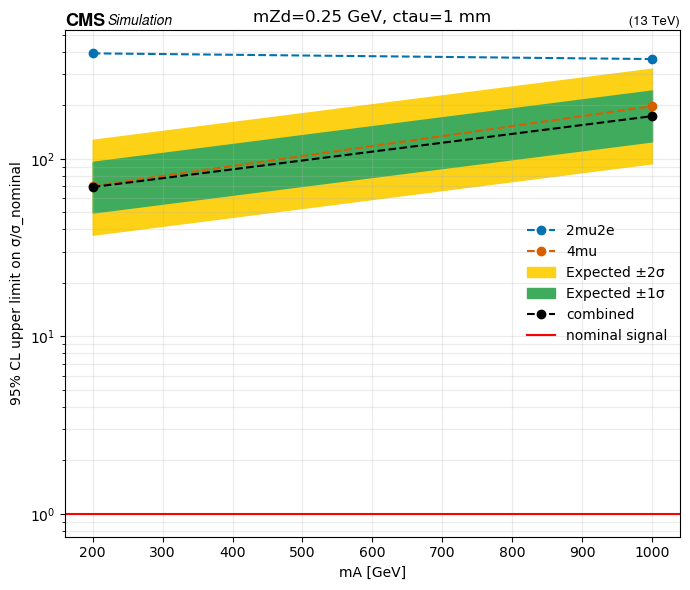

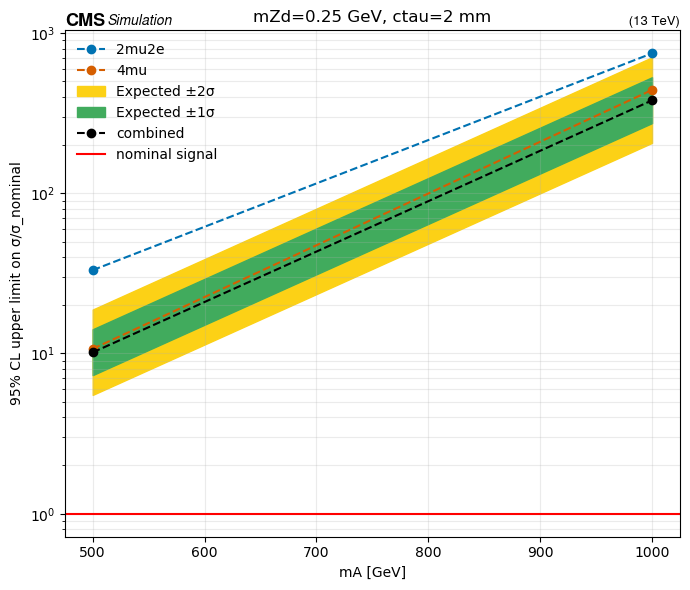

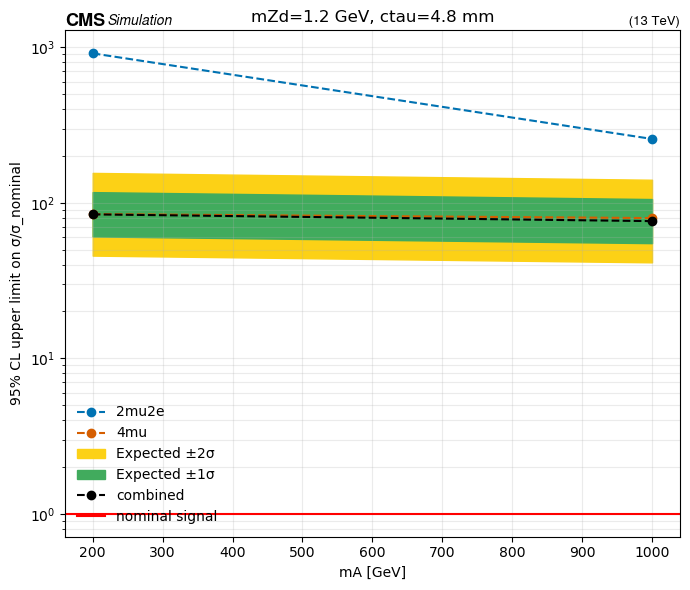

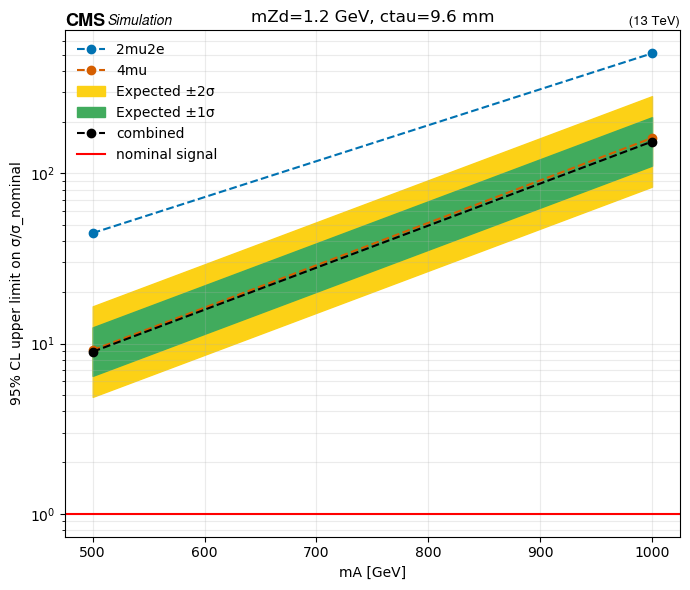

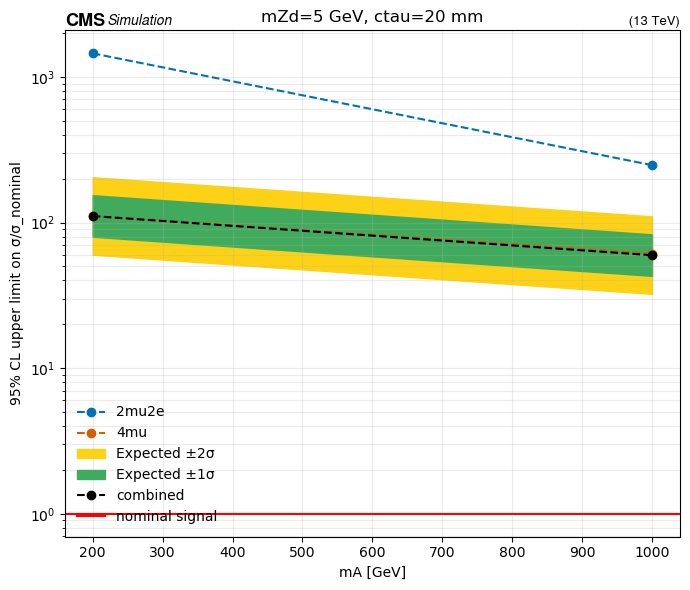

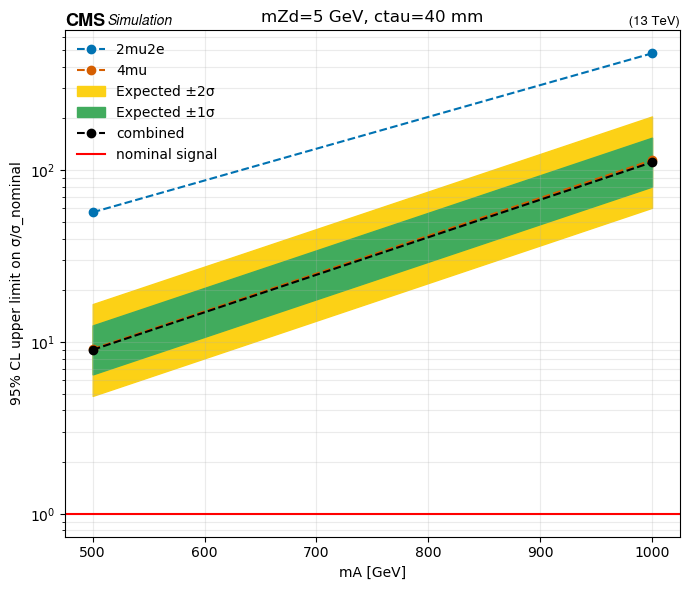

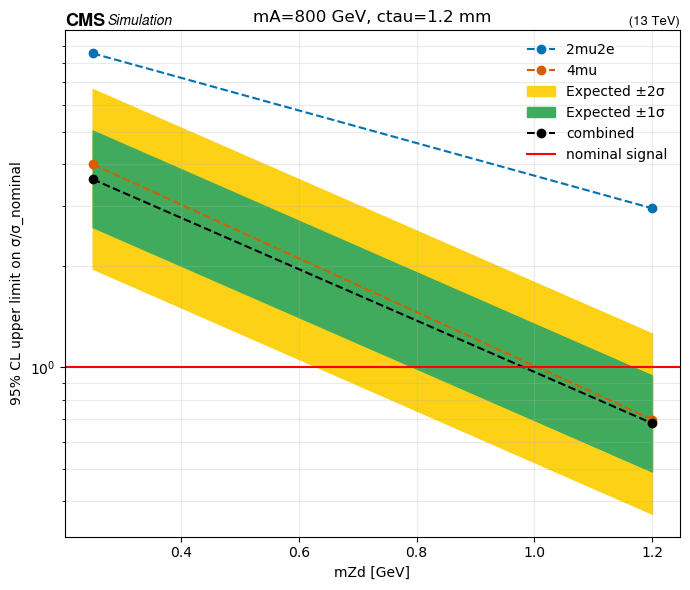

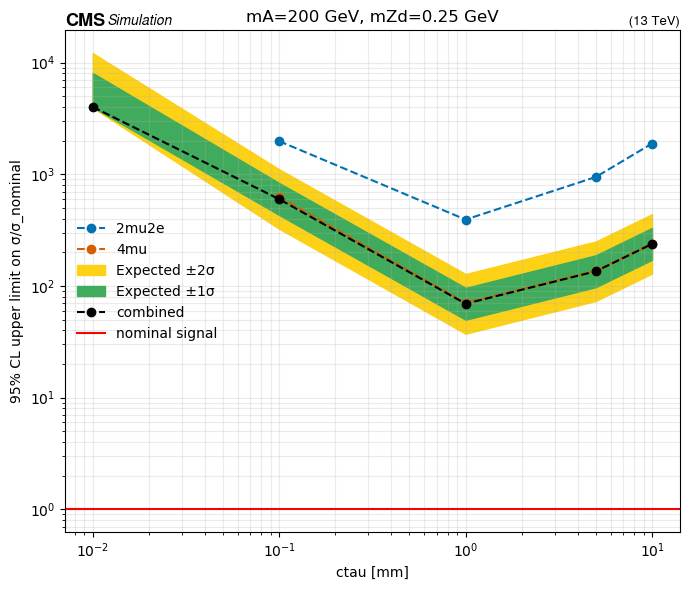

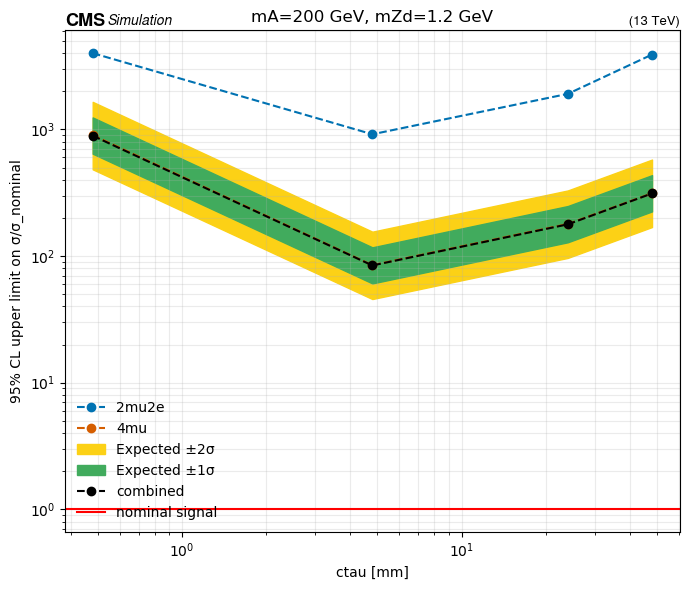

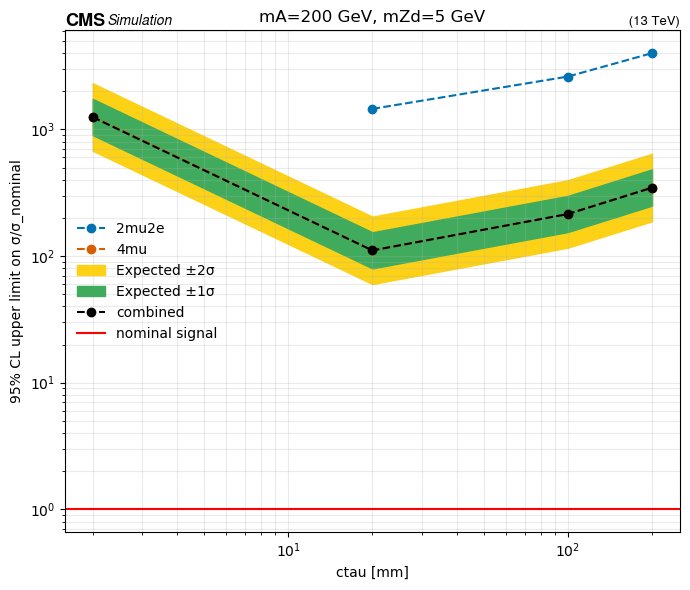

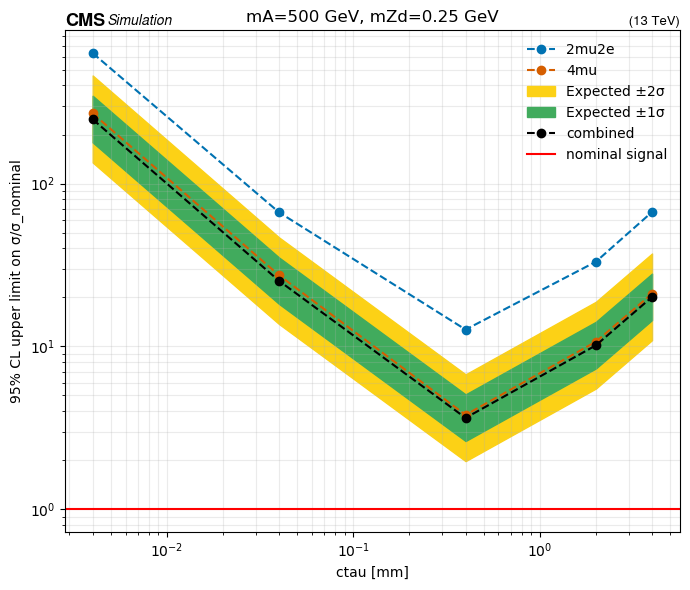

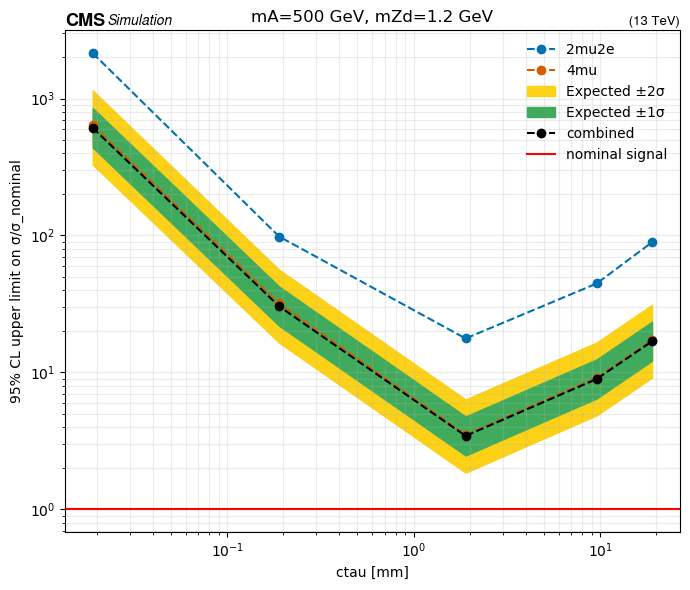

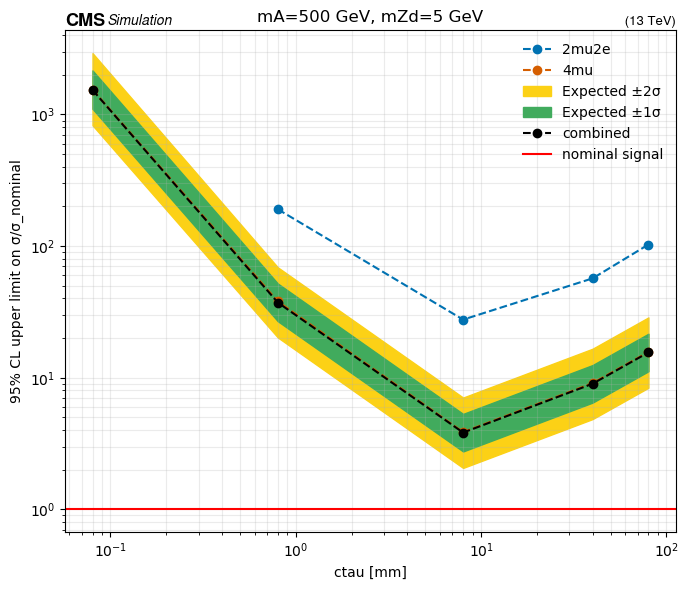

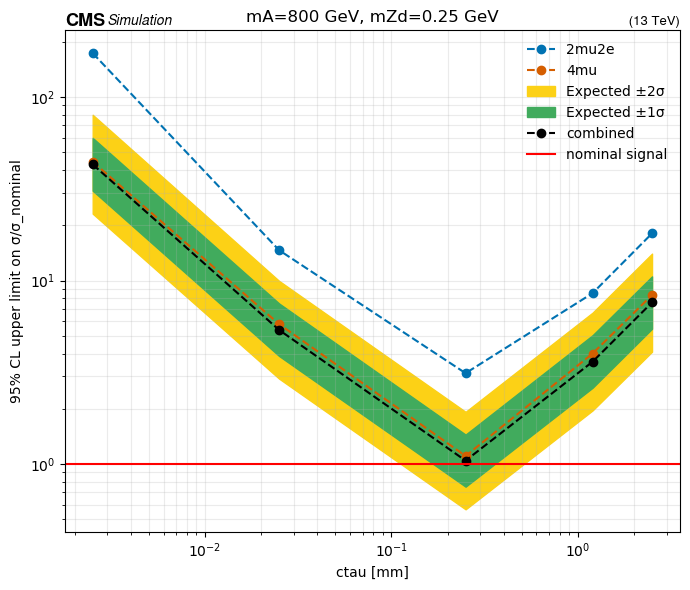

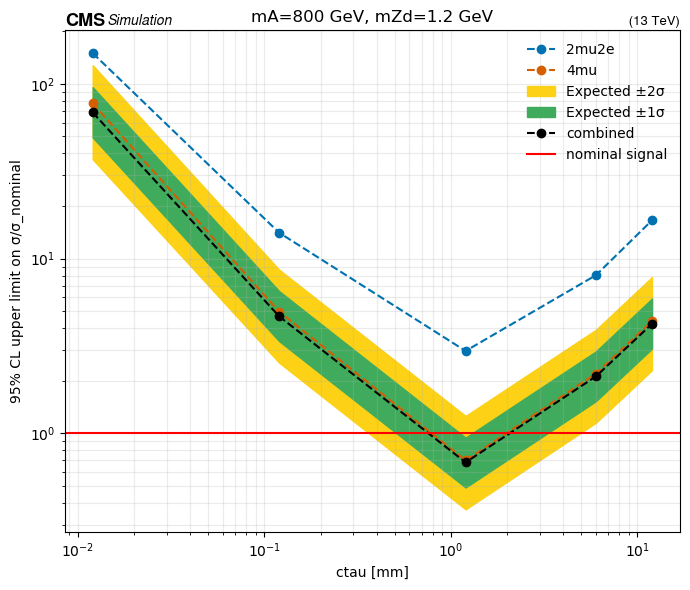

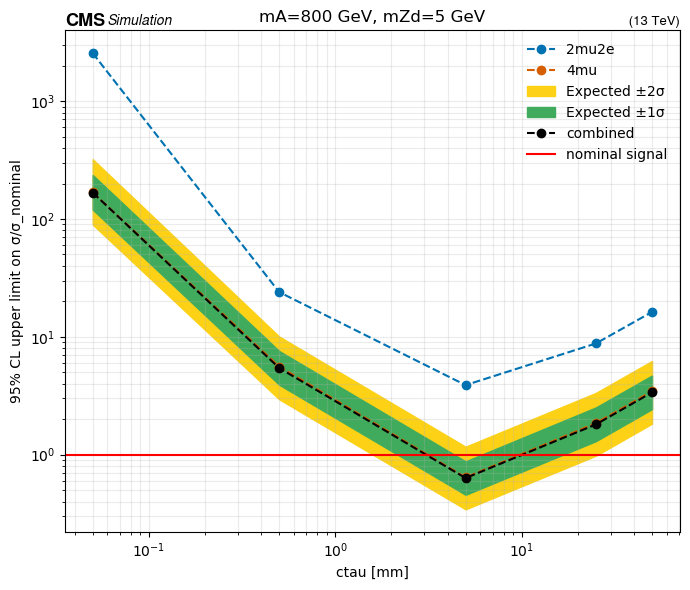

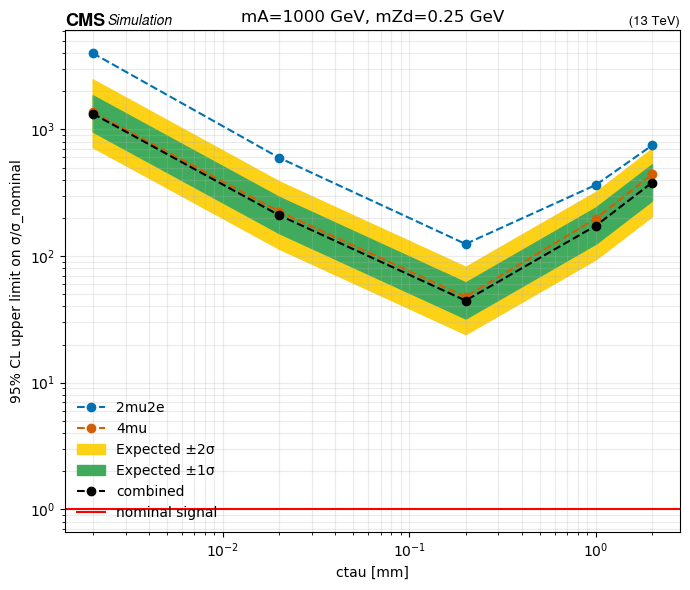

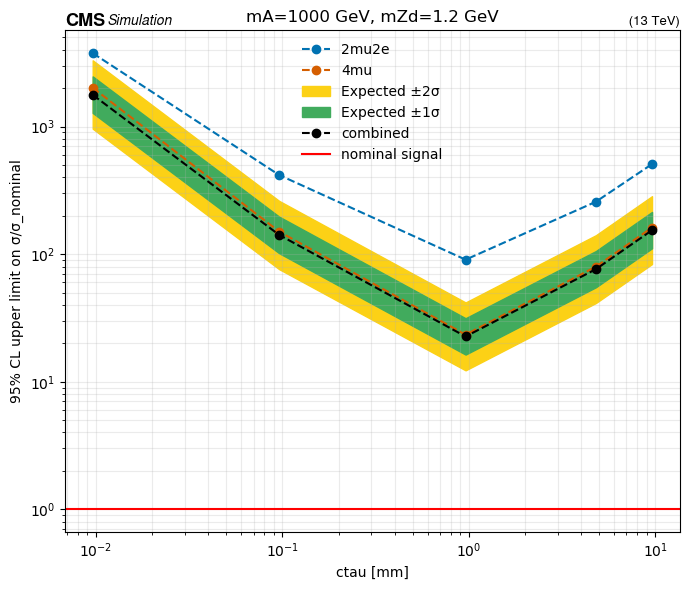

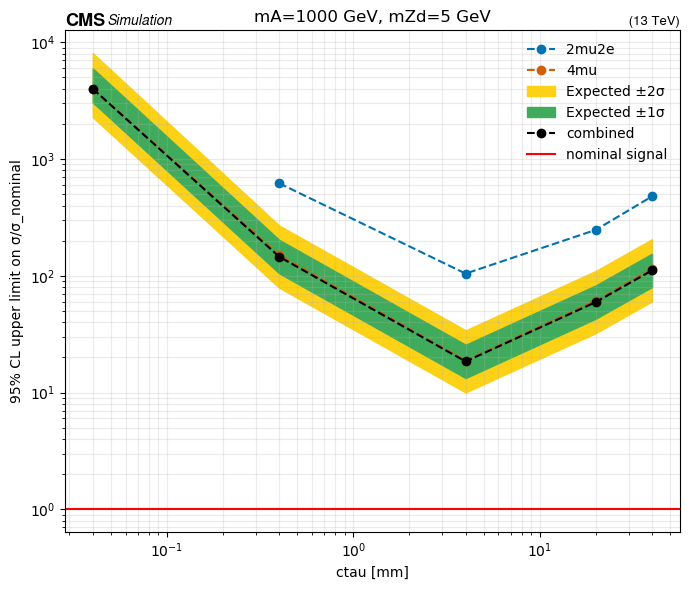

plots: 19


In [8]:
def plot_scan(frame,x,xlabel,title,path,logx=False):
    fig,ax=plt.subplots(figsize=(7,6)); colors={'2mu2e':'#0072B2','4mu':'#D55E00','combined':'black'}
    for channel,color in colors.items():
        selected=frame[frame.channel==channel].sort_values(x)
        if len(selected)<2: continue
        xv=selected[x].to_numpy(float)
        if channel=='combined':
            ax.fill_between(xv,selected.exp_m2,selected.exp_p2,color='#FCD116',label='Expected ±2σ')
            ax.fill_between(xv,selected.exp_m1,selected.exp_p1,color='#41AB5D',label='Expected ±1σ')
        ax.plot(xv,selected.exp_median,'o--',color=color,label=channel)
    if not ax.lines: plt.close(fig); return 0
    ax.axhline(1,color='red',label='nominal signal'); ax.set_yscale('log')
    if logx: ax.set_xscale('log')
    ax.set(xlabel=xlabel,ylabel='95% CL upper limit on σ/σ_nominal',title=title)
    ax.grid(True,which='both',alpha=.25); ax.legend(frameon=False); hep.cms.label(data=False,com=13,ax=ax)
    fig.tight_layout(); fig.savefig(path,dpi=180); plt.show(); plt.close(fig); return 1
nplots=0
if len(limits):
    for (mzd,ctau),f in limits.groupby(['mZd_GeV','ctau_mm']): nplots+=plot_scan(f,'mA_GeV','mA [GeV]',f'mZd={mzd:g} GeV, ctau={ctau:g} mm',PLOTS/f'mA_mZd{mzd:g}_ctau{ctau:g}mm.png')
    for (ma,ctau),f in limits.groupby(['mA_GeV','ctau_mm']): nplots+=plot_scan(f,'mZd_GeV','mZd [GeV]',f'mA={ma:g} GeV, ctau={ctau:g} mm',PLOTS/f'mZd_mA{ma:g}_ctau{ctau:g}mm.png')
    for (ma,mzd),f in limits.groupby(['mA_GeV','mZd_GeV']): nplots+=plot_scan(f,'ctau_mm','ctau [mm]',f'mA={ma:g} GeV, mZd={mzd:g} GeV',PLOTS/f'ctau_mA{ma:g}_mZd{mzd:g}.png',True)
print('plots:',nplots)


## Interpretation checklist

1. Data A는 어떤 표·카드·observation에도 사용되지 않았는지 확인한다.
2. κ의 상대오차와 plug-in prediction의 상대오차를 topology별로 확인한다.
3. smoke 세 카드에서 background autoMCStats nuisance와 signal-only luminosity nuisance를 확인한다.
4. 11번 대비 median-limit ratio의 topology 및 parameter dependence를 확인한다.
5. 이 근사가 안정적이면 다음 단계에서 B/C/D Poisson terms와 κ constraint를 직접 가진 simultaneous ABCD likelihood로 교체한다.
